In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import gmean, ttest_ind
from scipy.stats.mstats import winsorize

df = pd.read_csv('../data/cars_dataset.csv') # Путь к вашему файлу

print(df.head())
print(df.info())

   Unnamed: 0            mark        Box Drive_unit  Seats  Doors Country  \
0           0  Mercedes-Benz   automatic       full    5.0    5.0  German   
1           1  Mercedes-Benz   automatic       full    5.0    5.0  German   
2           2  Mercedes-Benz   automatic       full    5.0    5.0  German   
3           3  Mercedes-Benz   automatic       full    5.0    5.0  German   
4           4  Mercedes-Benz   automatic       full    5.0    5.0  German   

     Engine  Volume  Color  ...  Consumption               Engine_Power  \
0    diesel     2.9  black  ...          9.8                        NaN   
1    diesel     2.9  green  ...          9.6                        NaN   
2  gasoline     4.0  black  ...         12.1  direct injection (direct)   
3  gasoline     4.0  black  ...         12.1  direct injection (direct)   
4  gasoline     4.0   gray  ...         12.1  direct injection (direct)   

   Restyling Release_start_series End_Serial Trunk_volume_max  \
0        0.0         

### Лаба 1.1

#### 1.1 Типы шкал

## Типы шкал измерения переменных датасета

### Номинальные (категориальные)
brand, model, transmission, driveType, bodyType, fuelType, color,
engineType, cylinderLayout, brakeType, suspension, fuelGrade,
injectionType, enginePosition, tireSize, generation

### Порядковые (ординальные)
ecoClass

### Интервальная
year

### Шкала отношений
price, mileage, engineDisplacement, power, torque, curbWeight,
wheelbase, length, width, height, clearance, maxSpeed, acceleration,
fuelConsumptionCombined, fuelConsumptionUrban, fuelConsumptionExtraUrban,
tankCapacity, trunkVolumeMin, trunkVolumeMax, doors, cylinders,
compressionRatio, trackFront, trackRear

### Бинарные
isExport

In [4]:
target_col = 'Engine_Power'  # Замените на колонку с пропусками
df[f'{target_col}_missing'] = df[target_col].isna().astype(int)

group_volume = df.groupby(f'{target_col}_missing')['Volume'].mean()
print(f"Средний год выпуска (0-есть данные, 1-пропуск):\n{group_volume}\n")

group_price = df.groupby(f'{target_col}_missing')['Price'].mean()
print(f"Средняя цена (0-есть данные, 1-пропуск):\n{group_price}\n")

t_stat, p_val = ttest_ind(
    df[df[f'{target_col}_missing']==0]['Volume'].dropna(),
    df[df[f'{target_col}_missing']==1]['Volume'].dropna()
)
print(f"P-value для гипотезы о равенстве лет: {p_val:.4f}")

t_stat_price, p_val_price = ttest_ind(
    df[df[f'{target_col}_missing']==0]['Price'].dropna(),
    df[df[f'{target_col}_missing']==1]['Price'].dropna()
)
print(f"P-value для гипотезы о равенстве цен: {p_val_price:.4f}")
from scipy.stats import ttest_ind
mask_0 = df[f'{target_col}_missing'] == 0
mask_1 = df[f'{target_col}_missing'] == 1

p_volume = ttest_ind(df.loc[mask_0,'Volume'].dropna(),
                   df.loc[mask_1,'Volume'].dropna()).pvalue
p_price = ttest_ind(df.loc[mask_0,'Price'].dropna(),
                    df.loc[mask_1,'Price'].dropna()).pvalue

Средний год выпуска (0-есть данные, 1-пропуск):
Engine_Power_missing
0    2.325946
1    2.383156
Name: Volume, dtype: float64

Средняя цена (0-есть данные, 1-пропуск):
Engine_Power_missing
0    1.237946e+06
1    1.977199e+06
Name: Price, dtype: float64

P-value для гипотезы о равенстве лет: 0.0028
P-value для гипотезы о равенстве цен: 0.0000


#### 1.2 Сравнение признаков: model (Номинальная) и price (Отношений)

In [5]:

# Статистики для количественной переменной (шкала отношений)
stats_price = {
    "Среднее": df['Price'].mean(),
    "Медиана": df['Price'].median(),
    "Мода": df['Price'].mode()[0]
}

# Статистики для номинальной переменной (категориальная)
stats_volume = {
    "Среднее": df['Volume'].mean(),
    "Медиана": df['Volume'].median(),
    "Мода": df['Volume'].mode()[0]
}

print(f"Статистики Price: {stats_price}")
print(f"Статистики Volume: {stats_volume}")

Статистики Price: {'Среднее': np.float64(1353936.4108448594), 'Медиана': np.float64(680000.0), 'Мода': np.float64(350000.0)}
Статистики Volume: {'Среднее': np.float64(2.334922033301031), 'Медиана': np.float64(2.0), 'Мода': np.float64(1.6)}


Для номинальной шкалы (`mark`, `Box`, `Country`, `Engine`) единственная корректная мера центральной тенденции — **мода**. Попытка посчитать среднее значение или медиану для категорий (даже если они закодированы цифрами) приведёт к получению информации, не имеющей физического смысла и не несущей аналитической ценности.

Для количественных шкал отношений (`Price`, `Engine_volume`, `Engine_Power`) допустимы все меры центральной тенденции: среднее, медиана и мода, а также показатели вариации (стандартное отклонение, квантили). Однако при наличии выбросов (например, экстремально дорогие авто) **медиана** предпочтительнее среднего как робастная оценка.

Для интервальной шкалы (`Year`) среднее и медиана имеют смысл для описания «типичного года выпуска», но операции типа «в 2 раза новее» некорректны из-за отсутствия абсолютного нуля.


### 2. Диагностика типа пропусков

### Выбранный признак: `Engine_Power` (мощность двигателя)

#### H₀: MCAR — пропуски полностью случайны
**Суть**: Пропуски не зависят ни от чего.

**Проверка**:

In [6]:
df['fc_missing'] = df['Engine_Power'].isna().astype(int)
# t-тест: различия в цене/годе между группами с/без пропусков
from scipy.stats import ttest_ind
p_volume = ttest_ind(df[df['fc_missing']==0]['Volume'], df[df['fc_missing']==1]['Volume']).pvalue
p_price = ttest_ind(df[df['fc_missing']==0]['Price'], df[df['fc_missing']==1]['Price']).pvalue

print(f"p-value Volume: {p_volume:.4f}, Price: {p_price:.4f}")

p-value Volume: 0.0028, Price: 0.0000


#### H₁: MAR — пропуски зависят от наблюдаемых признаков
**Суть**: Пропуски связаны с `fuelType`, `Year`, `Price`.

**Проверка**:

In [7]:
print(df.groupby('Fuel')['fc_missing'].mean())

Fuel
AI-76     0.000000
AI-80     0.023529
AI-92     0.007377
AI-95     0.001124
AI-98     0.000000
GAZ       0.000000
diesel    0.970483
Name: fc_missing, dtype: float64


MAR подтверждается, если есть значимые различия (p < 0.05) или явный паттерн по категориям.

#### H₂: MNAR — пропуски зависят от самого пропущенного значения
**Суть**: Расход не указывают, если он экстремальный.

**Проверка**:

In [8]:
electro_rate = df[df['Fuel']=='diesel']['fc_missing'].mean()
other_rate = df[df['Fuel']!='diesel']['fc_missing'].mean()
print(f"Пропуски: diesel={electro_rate*100:.1f}%, другие={other_rate*100:.1f}%")

Пропуски: diesel=97.0%, другие=1.6%


### 3. Индикатор пропуска как источник информации
1. Объясните, в каком случае сам факт пропуска несёт информацию.

Сам факт пропуска несёт информацию, когда данные пропущены не случайно:
###### MAR — пропуски объясняются другими наблюдаемыми переменными
###### MNAR — пропуски связаны с самим пропущенным значением

2. Почему значимость индикатора в модели - это сигнал о неправильной или грубой
импутации?
###### Мы создаем шум: На самом деле группа с пропусками могла иметь другое распределение
###### Мы теряем важный сигнал: Модель "говорит" нам, что сам факт пропуска важен для предсказания, а мы вместо него поставили среднее значение

3. Приведите пример признака, для которого индикатор пропуска:
###### полезен:
Consumption_average. Можно предположить что это пропуск MAR (зависит от Fuel), тогда индикатор может быть полезен для отличия дизельных авто от бензиновых с пропущенными данными
###### бесполезен:
color. Так как это MCAR — пропуски распределены равномерно (ошибка парсинга), индикатор не улучшает модель, только добавляет шум
###### опасен:
Year (при импутации средним). Может возникнуть ложная связь: среднее года (2010.7) не имеет физического смысла, индикатор становится «костылём», маскирующим ошибку импутации

### 4. Выброс — ошибка или сигнал?

count    22702.000000
mean         2.334922
std          1.049301
min          0.000000
25%          1.600000
50%          2.000000
75%          2.700000
max          8.100000
Name: Volume, dtype: float64

Границы для выбросов (IQR метод):
Нижняя граница: -0.05
Верхняя граница: 4.35
Количество выбросов: 1644
Процент выбросов: 7.24%

Топ-5 максимальных значений Volume:
22166    8.1
22167    8.1
22257    8.1
22258    8.1
21501    7.7
Name: Volume, dtype: float64

Топ-5 минимальных значений Volume:
4096    0.0
4360    0.0
4840    0.0
4841    0.0
4842    0.0
Name: Volume, dtype: float64


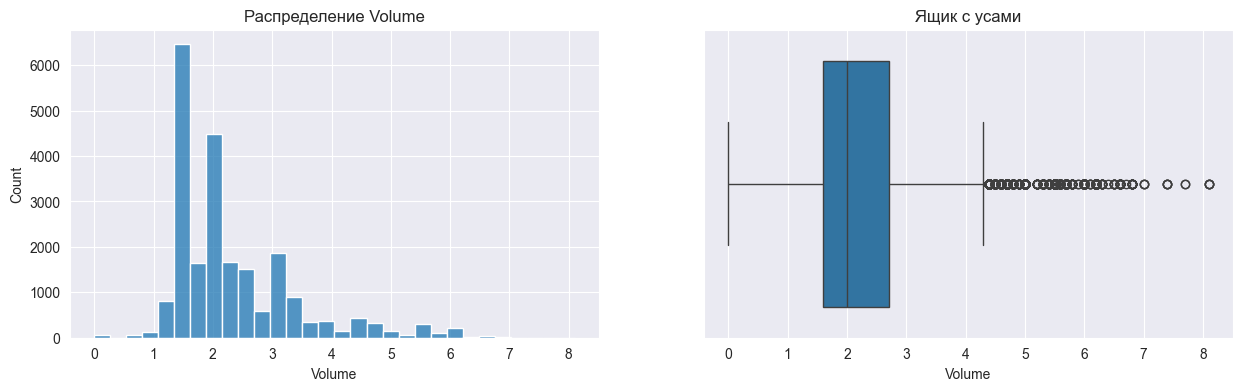

In [9]:
con = 'Volume'
print(df[con].describe())

fig, axes = plt.subplots(1, 2, figsize=(15, 4))

sns.histplot(df[con], bins=30, ax=axes[0])
axes[0].set_title(f'Распределение {con}')

sns.boxplot(x=df[con], ax=axes[1])
axes[1].set_title('Ящик с усами')

Q1 = df[con].quantile(0.25)
Q3 = df[con].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df[con] < lower_bound) | (df[con] > upper_bound)]
print(f"\nГраницы для выбросов (IQR метод):")
print(f"Нижняя граница: {lower_bound:.2f}")
print(f"Верхняя граница: {upper_bound:.2f}")
print(f"Количество выбросов: {len(outliers)}")
print(f"Процент выбросов: {len(outliers)/len(df)*100:.2f}%")


print(f"\nТоп-5 максимальных значений {con}:")
print(df[con].nlargest(5))

print(f"\nТоп-5 минимальных значений {con}:")
print(df[con].nsmallest(5))

#### Анализ признака Volume(объем двигателя):


 1. Реальные причины значений > 6 л:
- **Премиум/люкс сегмент**: большие атмосферные и турбо-двигатели для тяжёлых внедорожников
- **Спорт-версии и тюнинг**: форсированные моторы для высокой мощности (AMG, M-серия)
- **Коммерческий транспорт**: микроавтобусы и пикапы с дизельными моторами большого объёма


 2. Что хуже для анализа:

| Вариант | Последствия |
|---------|-------------|
| **Удалить выброс** | Потеря информации о премиум-сегменте; модель будет хуже предсказывать цены на мощные авто; смещение выборки в сторону масс-маркета |
| **Оставить без изменений** | Линейные модели дадут смещённые коэффициенты; метрики (MAE/RMSE) ухудшатся из-за экстремумов; риск переобучения на редких значениях |


### 5. Визуализация как инструмент мышления

Text(0.5, 1.0, 'Распределение Volume')

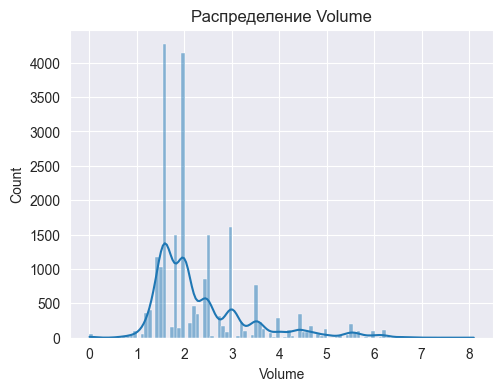

In [10]:
column = 'Volume'
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
sns.histplot(df[column], kde=True)
plt.title(f'Распределение {column}')

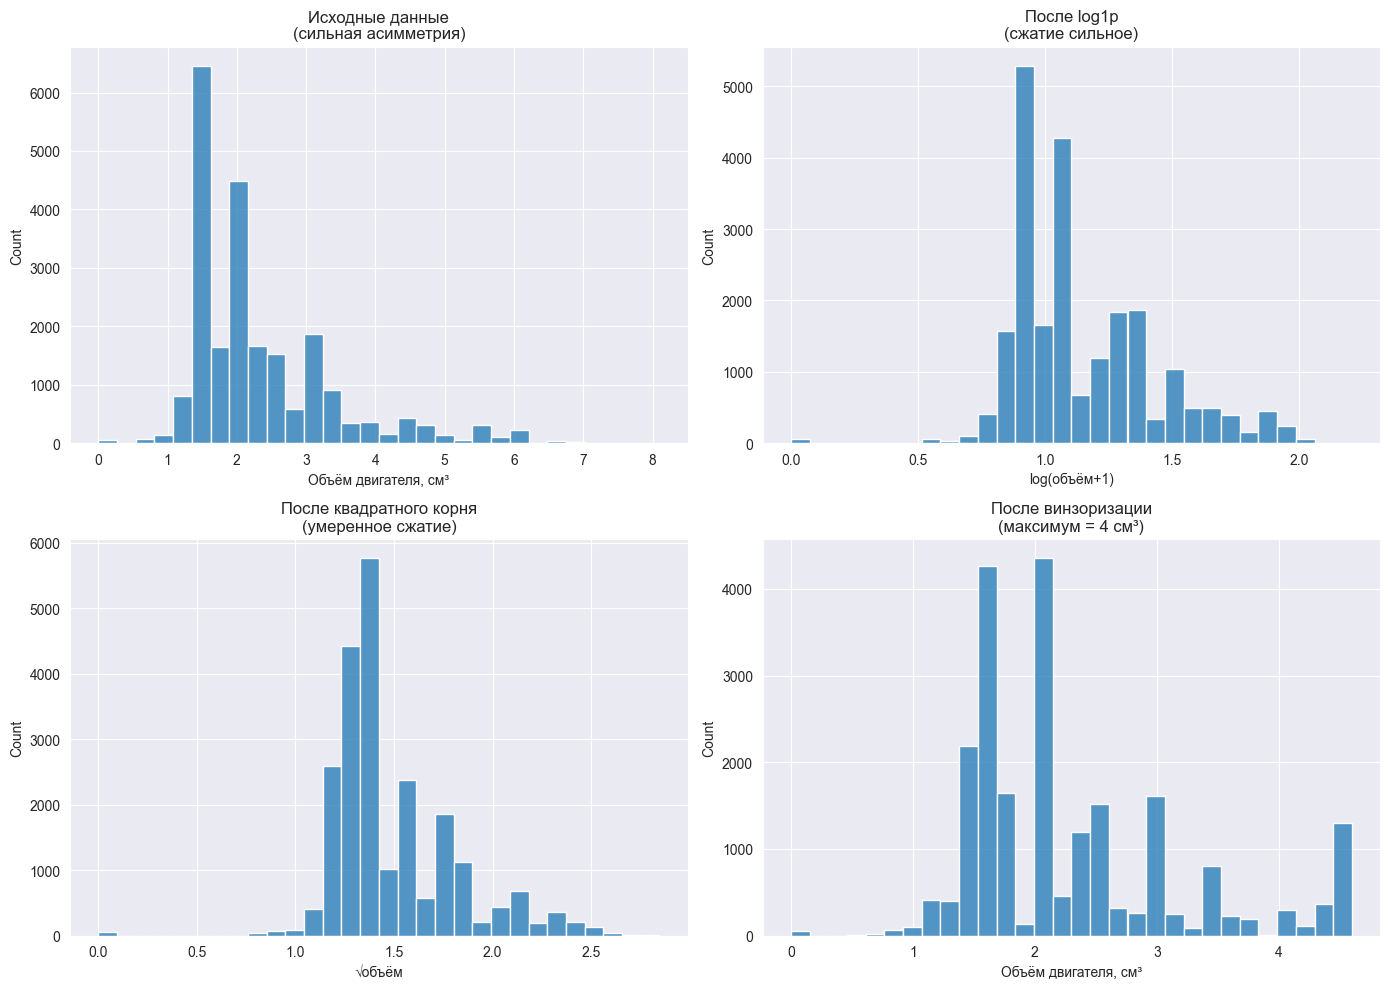

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

con = "Volume"
sns.histplot(df[con], bins=30, ax=axes[0,0])
axes[0,0].set_title('Исходные данные\n(сильная асимметрия)')
axes[0,0].set_xlabel('Объём двигателя, см³')


sns.histplot(np.log1p(df[con]), bins=30, ax=axes[0,1])
axes[0,1].set_title('После log1p\n(сжатие сильное)')
axes[0,1].set_xlabel('log(объём+1)')


sns.histplot(np.sqrt(df[con]), bins=30, ax=axes[1,0])
axes[1,0].set_title('После квадратного корня\n(умеренное сжатие)')
axes[1,0].set_xlabel('√объём')

upper = df[con].quantile(0.95)
df_winsor = df[con].clip(upper=upper)
sns.histplot(df_winsor, bins=30, ax=axes[1,1])
axes[1,1].set_title(f'После винзоризации\n(максимум = {int(upper)} см³)')
axes[1,1].set_xlabel('Объём двигателя, см³')

plt.tight_layout()
plt.show()

##### интерпретируемость:
###### логарифмирование — сильное искажение: коэффициенты модели интерпретируются как «изменение на 1% признака», что не всегда интуитивно
###### корень — сильное искажение: единицы измерения становятся «√см³», физический смысл теряется
###### винзоризация — низкое искажение: единицы сохраняются, интерпретация остаётся прямой («см³»)

##### линейные модели:
###### логарифмирование — улучшает: снижает влияние выбросов, стабилизирует дисперсию, лучше для мультиколлинеарности
###### корень — улучшает: умеренное сжатие хвоста, подходит для умеренной асимметрии
###### винзоризация — улучшает: обрезает экстремумы, но может потерять информацию о премиум-сегменте

##### визуализация распределения:
###### логарифмирование — сильное: делает распределение близким к нормальному, удобна для анализа
###### корень — сильное: смягчает асимметрию, но менее эффективно для очень скошенных данных
###### винзоризация — среднее: сохраняет форму основной массы данных, но «обрезает» правый хвост

##### Когда что предпочтительнее:
###### логарифмирование — когда асимметрия очень сильная (skew > 2), данные охватывают несколько порядков (100–10 000 см³), цель — прогноз в лог-шкале
###### корень — когда асимметрия умеренная (skew 1–2), нужно мягкое сжатие без потери интерпретируемости
###### винзоризация — когда выбросы — это артефакты (ошибки парсинга), или когда важно сохранить исходные единицы для бизнес-отчётности

### 6. Средние, которые вводят в заблуждение

Арифметическое среднее: 2.33 л
Медиана: 2.00 л
Геометрическое среднее: 2.16 л


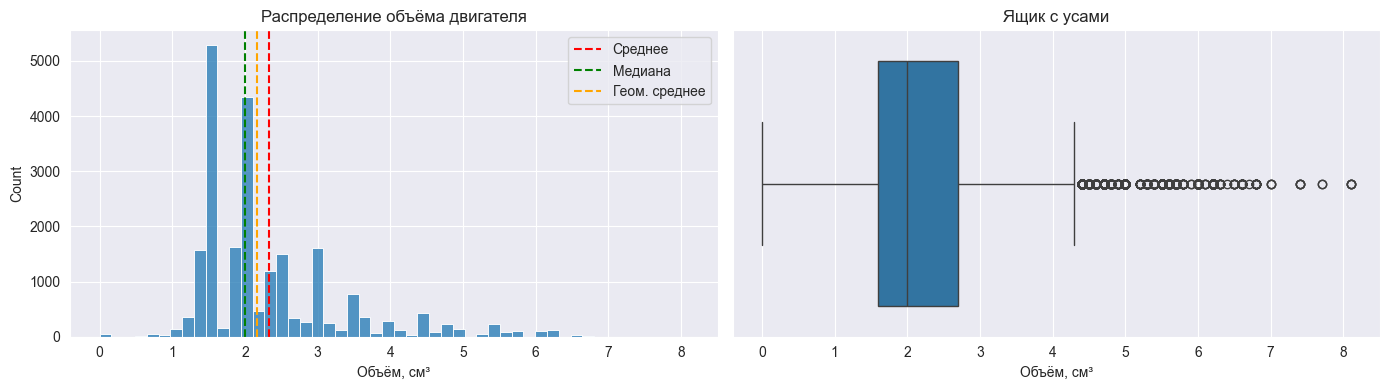

In [14]:
con = 'Volume'
mean_arith = df[con].mean()
median = df[con].median()
# Геометрическое только для положительных значений
df_pos = df[df[con] > 0]
mean_geom = np.exp(np.log(df_pos[con]).mean())

print(f"Арифметическое среднее: {mean_arith:,.2f} л")
print(f"Медиана: {median:,.2f} л")
print(f"Геометрическое среднее: {mean_geom:,.2f} л")

# Визуализация
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(df[con], bins=50, ax=axes[0])
axes[0].axvline(mean_arith, color='red', linestyle='--', label='Среднее')
axes[0].axvline(median, color='green', linestyle='--', label='Медиана')
axes[0].axvline(mean_geom, color='orange', linestyle='--', label='Геом. среднее')
axes[0].set_title('Распределение объёма двигателя')
axes[0].legend()
axes[0].set_xlabel('Объём, см³')

sns.boxplot(x=df[con], ax=axes[1])
axes[1].set_title('Ящик с усами')
axes[1].set_xlabel('Объём, см³')
plt.tight_layout()
plt.show()

###### Почему они различаются:
- **Правосторонняя асимметрия**: большинство авто имеют двигатели 1.4–2.5 л (1400–2500 см³), но есть единичные экземпляры с моторами 5.0–6.2 л (5000–6200 см³)
- **Арифметическое среднее** «тянется» за выбросами: один двигатель 6162 см³ (Cadillac Escalade) эквивалентен ~3 авто по 2000 см³
- **Медиана** игнорирует экстремумы: показывает объём, ниже и выше которого находится по 50% выборки (~2.0 л — типичный современный двигатель)
- **Геометрическое среднее** работает в лог-шкале: сжимает диапазон, но даёт значение, которое трудно объяснить заказчику («средний двигатель 2180 см³» менее интуитивно, чем «медиана 2.0 л»)

### 7. Неправильная диаграмма

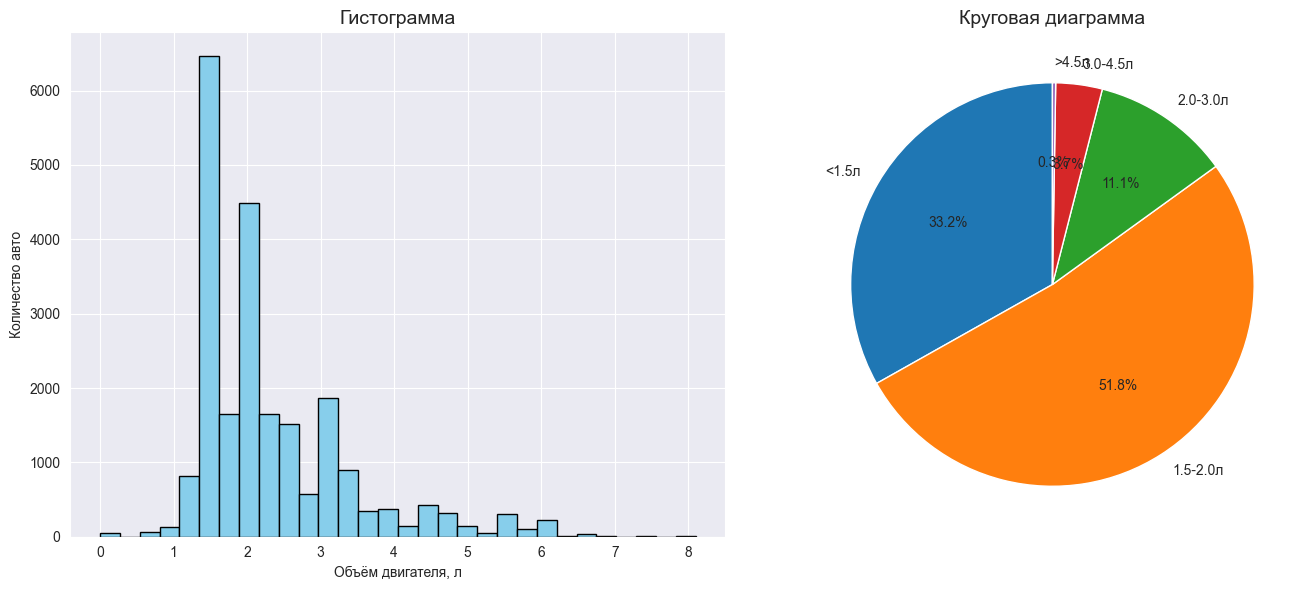

In [16]:
con = 'Volume'
data = df[con]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Гистограмма — подходящий вариант
axes[0].hist(data.dropna(), bins=30, color='skyblue', edgecolor='black')
axes[0].set_title('Гистограмма', fontsize=14)
axes[0].set_xlabel('Объём двигателя, л')
axes[0].set_ylabel('Количество авто')

# Круговая диаграмма — неподходящий вариант
bins = pd.cut(data.dropna(), bins=5, labels=['<1.5л', '1.5-2.0л', '2.0-3.0л', '3.0-4.5л', '>4.5л'])
counts = bins.value_counts().sort_index()
axes[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%', startangle=90)
axes[1].set_title('Круговая диаграмма', fontsize=14)

plt.tight_layout()
plt.show()

#### Доказательство: Круговая диаграмма хуже гистограммы для данных `Volume`

- **Слишком много уникальных значений** (непрерывная величина) для круговой диаграммы — требуется группировка, которая скрывает детали распределения
- **Потеря информации о форме распределения**: правосторонняя асимметрия и выбросы (>6000 см³) не видны
- **Невозможность точного сравнения**: сектора 3.0-4.5л и >4.5л визуально сложно сопоставить
- **Искажение восприятия частот**: малые доли (премиум-сегмент) выглядят «нормально», хотя это <2% выборки

#### Описание

##### Какую информацию он бы исказил:
- **Асимметрию распределения**: гистограмма показывает длинный правый хвост (редкие большие двигатели), круговая — «усредняет» его в сектор
- **Выбросы**: двигатели >6 л (премиум/спорт) сливаются с группой 3.0-4.5л, теряется маркер сегмента
- **Моду распределения**: пик на 1.6-2.0 л (масс-маркет) не выделяется визуально среди других секторов
- **Порядок значений**: круговая диаграмма не передаёт естественный порядок «меньше → больше»

##### Какой неверный вывод мог бы сделать зритель:
- «Большинство авто имеют двигатели 2.0-3.0 л» — хотя на самом деле мода в диапазоне 1.6-2.0 л
- «Премиум-сегмент (двигатели >4.5 л) представлен широко» — хотя это <2% выборки, но сектор выглядит значимым из-за визуального веса
- «Распределение равномерное» — хотя данные сильно скошены вправо, что критично для выбора модели прогнозирования цены


### Задание 8. Одна и та же информация — разные графики

###### Выбранная пара признаков: `Volume` (объём двигателя, л) и `Maximum_power` (мощность, л.с.)

#### График 1: Диаграмма рассеяния (Scatter Plot)


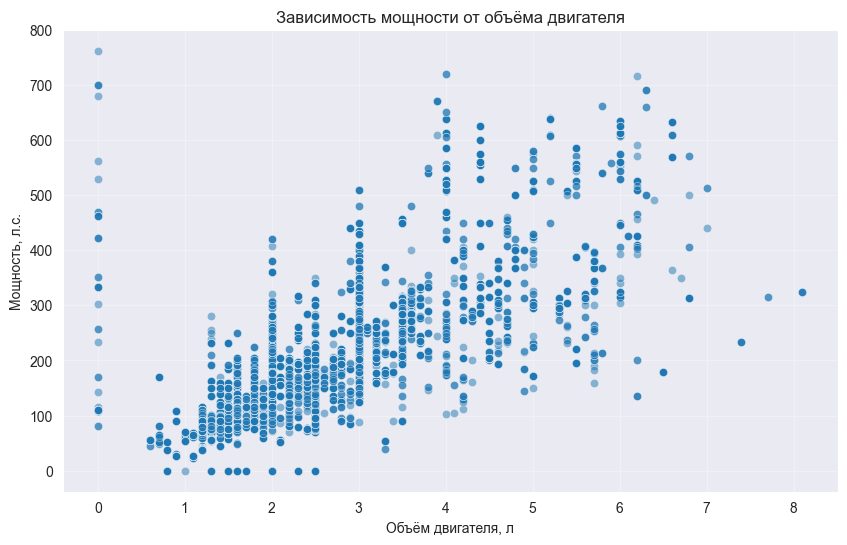

In [19]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Volume', y='Maximum_power', alpha=0.5)
plt.title('Зависимость мощности от объёма двигателя')
plt.xlabel('Объём двигателя, л')
plt.ylabel('Мощность, л.с.')
plt.grid(True, alpha=0.3)
plt.show()

###### Подчёркивает:
- **Форму зависимости** — видно, линейная она или нет (например, рост мощности замедляется после 3000 см³ из-за разных технологий)
- **Плотность распределения** — где точек больше, там гуще (основная масса авто в диапазоне 1400–2500 см³ и 100–150 л.с.)
- **Выбросы** — точки, далеко отстоящие от основного облака (например, турбо-моторы с высокой мощностью при малом объёме)
- **Границы значений** — минимальные и максимальные значения по обеим осям
- **Кластеры** — если есть отдельные группы (например, атмосферные ДВС и турбо-моторы образуют разные облака)

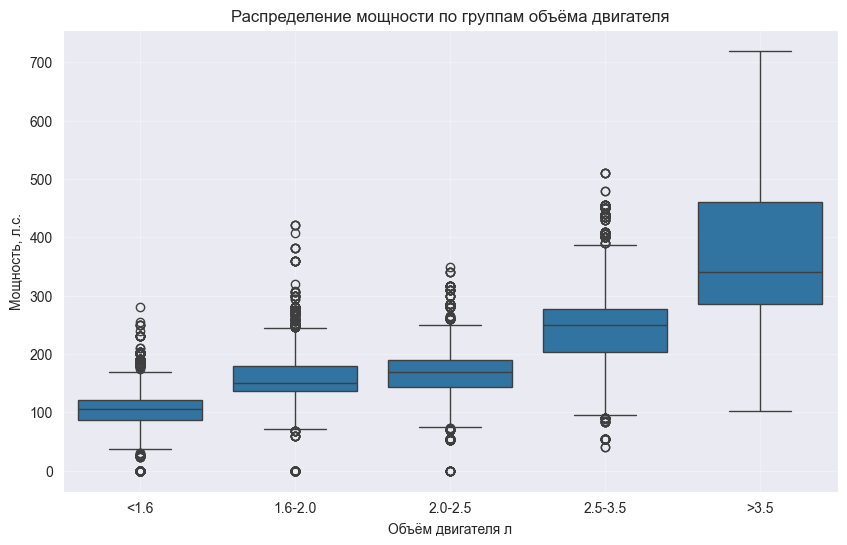

In [20]:
df['Engine_Category'] = pd.cut(df['Volume'],
                                bins=[0, 1.600, 2.000, 2.500, 3.500, 7.000],
                                labels=['<1.6', '1.6-2.0', '2.0-2.5', '2.5-3.5', '>3.5'])

plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Engine_Category', y='Maximum_power')
plt.title('Распределение мощности по группам объёма двигателя')
plt.xlabel('Объём двигателя л')
plt.ylabel('Мощность, л.с.')
plt.grid(True, alpha=0.3)
plt.show()

###### Подчёркивает:
- **Медианные значения** — центральная линия в каждом ящике (типичная мощность для категории объёма)
- **Разброс внутри группы** — высота ящика (IQR), показывающая вариабельность мощности при одинаковом объёме
- **Выбросы в каждой группе** — точки за усами (например, турбо-версии с аномально высокой мощностью)
- **Сравнение групп** — удобно сравнивать медианы и разброс между категориями двигателей


#### Гипотезы, которые легче заметить на диаграмме рассеяния:
- **Существует нелинейная зависимость** — если точки образуют кривую (например, мощность растёт быстро до 2.0 л, затем медленнее из-за разных технологий)
- **Есть кластеры по типу наддува** — если раскрасить точки по `engineType`, видны отдельные облака для атмосферных и турбо-моторов
- **Выбросы имеют технический контекст** — видно, что авто с малым объёмом, но высокой мощностью — это турбо-версии, а не ошибка

#### Гипотезы, которые легче заметить на ящиках с усами:
- **"Моторы >3.5 л имеют более стабильную мощность"**
  Видно по высоте ящика (меньший относительный разброс) и положению медианы
  *На scatter plot разброс оценить сложнее из-за наложения точек*

- **"Медианная мощность растёт с увеличением объёма двигателя"**
  Сравнение медиан по группам очень наглядно
  *На scatter plot медиану не видно без дополнительных расчётов*

- **"В группе 2.0-2.5 л есть моторы с аномально низкой мощностью"**
  Выбросы сразу видны точками за нижним усом
  *На scatter plot выбросы тоже видны, но их сложнее связать с конкретной группой*

- **"Распределение мощности в группе <1.6 л сильно скошено вправо"**
  Видно по положению медианы ближе к нижнему краю ящика
  *На scatter plot асимметрию оценить сложно без гистограммы*